In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To make plots pretty
sns.set(style="whitegrid")


In [2]:
# Load your CSV (adjust path if needed)
df = pd.read_csv('../data/raw/delhi_aqi.csv')

# Show basic info
df.head()


,datetime,tempmax,tempmin,temp,dew,winddir,sealevelpressure,cloudcover,visibility,PM2.5,...,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI
0,01-01-2015,21.0,9.0,14.4,10.6,10.9,1017.0,58.9,0.7,313.22,...,69.16,36.39,110.59,33.85,14.31,10.34,41.68,13.47,24.86,472.0
1,02-01-2015,15.5,12.0,14.2,12.8,95.6,1018.0,81.4,1.4,186.18,...,62.09,32.87,88.14,31.83,8.07,8.17,29.97,10.32,20.09,454.0
2,03-01-2015,17.0,13.0,14.8,13.5,303.9,1017.3,92.9,0.9,87.18,...,25.73,30.31,47.95,69.55,7.84,2.30,19.71,3.67,10.23,143.0
3,04-01-2015,18.0,10.0,13.8,10.9,296.7,1019.2,46.5,0.8,151.84,...,25.01,36.91,48.62,130.36,9.64,5.19,25.36,4.28,9.71,319.0
4,05-01-2015,20.5,8.0,13.1,8.5,288.5,1016.3,12.7,1.6,146.60,...,14.01,34.92,38.25,122.88,6.69,3.71,23.20,3.08,6.21,325.0


In [3]:
df.info()  # Data types, non-null values
df.describe()  # Stats summary


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1927 entries, 0 to 1926
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          1927 non-null   object 
 1   tempmax           1927 non-null   float64
 2   tempmin           1927 non-null   float64
 3   temp              1927 non-null   float64
 4   dew               1927 non-null   float64
 5   winddir           1927 non-null   float64
 6   sealevelpressure  1927 non-null   float64
 7   cloudcover        1927 non-null   float64
 8   visibility        1927 non-null   float64
 9   PM2.5             1925 non-null   float64
 10  PM10              1927 non-null   float64
 11  NO                1927 non-null   float64
 12  NO2               1927 non-null   float64
 13  NOx               1927 non-null   float64
 14  NH3               1927 non-null   float64
 15  CO                1927 non-null   float64
 16  SO2               1927 non-null   float64


,tempmax,tempmin,temp,dew,winddir,sealevelpressure,cloudcover,visibility,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI
count,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1925.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000
mean,31.211520,19.631136,25.123975,16.258952,215.865231,1009.006850,32.085262,2.538661,118.026686,237.164038,40.252696,51.953766,60.145511,42.478415,1.851707,16.031966,51.462507,3.656331,16.689014,262.253762
std,7.112874,7.657844,7.383848,6.372999,97.549340,7.000932,26.964087,0.866580,81.234594,119.355664,33.488052,22.390885,37.663999,17.452540,2.253014,7.929740,25.932155,2.609257,14.592604,117.175253
min,9.100000,3.000000,6.500000,3.700000,0.300000,991.700000,0.000000,0.100000,10.340000,18.590000,3.570000,10.630000,0.000000,6.780000,0.000000,2.300000,6.940000,0.000000,0.000000,29.000000
25%,25.850000,12.800000,18.600000,11.000000,109.650000,1002.800000,6.400000,1.900000,59.280000,147.415000,17.205000,34.890000,33.370000,31.585000,0.940000,10.430000,33.875000,1.900000,6.500000,170.000000
50%,32.600000,21.000000,27.200000,15.100000,270.600000,1009.400000,28.200000,2.700000,96.890000,230.340000,28.910000,48.330000,54.070000,38.840000,1.260000,15.110000,45.160000,3.080000,12.580000,262.000000
75%,36.000000,26.600000,31.100000,22.650000,290.550000,1015.100000,53.950000,3.200000,154.260000,311.450000,52.900000,64.095000,76.900000,49.350000,1.810000,19.680000,60.260000,4.920000,22.715000,346.000000
max,47.000000,34.600000,39.400000,27.600000,358.400000,1022.700000,100.000000,4.900000,685.360000,796.880000,221.030000,162.500000,254.800000,166.700000,36.500000,71.560000,257.730000,22.460000,97.470000,716.000000


In [4]:
# Convert datetime column (with dayfirst=True)
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)

# Set datetime as index (optional but useful for time-based analysis)
df.set_index('datetime', inplace=True)

# Check date range
print(f"Date range: {df.index.min()} to {df.index.max()}")


Date range: 2015-01-01 00:00:00 to 2020-04-10 00:00:00


In [5]:
# Check how many missing values are in each column
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)


PM2.5    2
dtype: int64

In [6]:
# Drop rows where PM2.5 is missing
df.dropna(subset=['PM2.5'], inplace=True)

# Confirm it's clean
df.isnull().sum().sum()  # should return 0


0

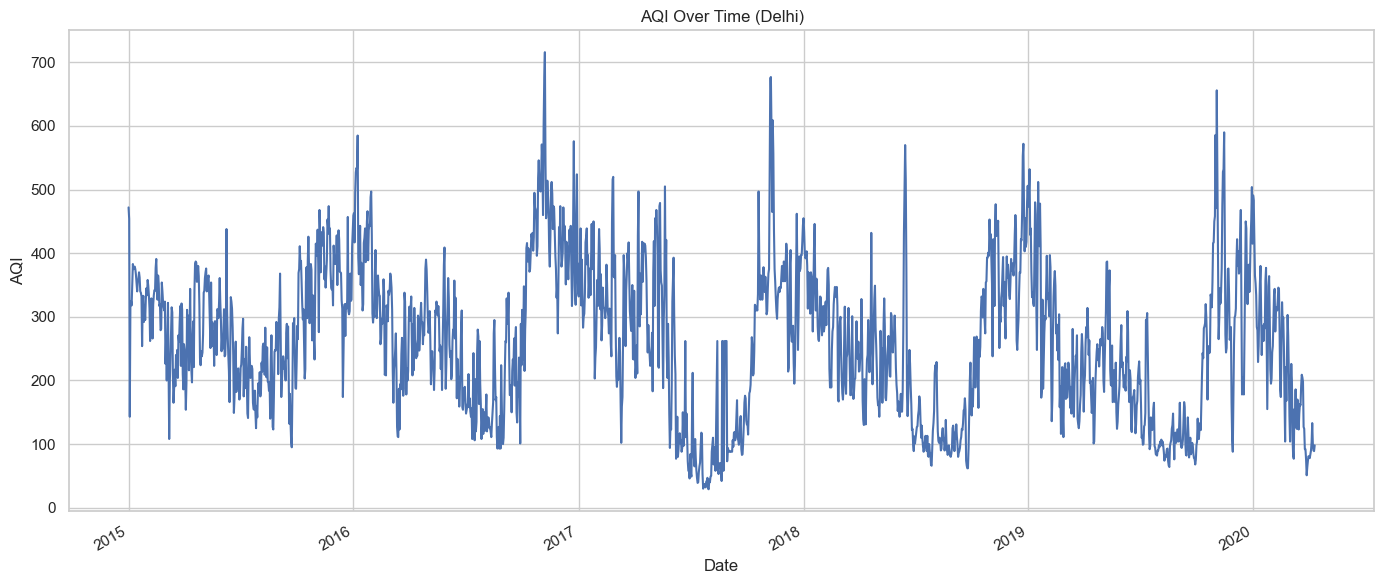

In [7]:
plt.figure(figsize=(14,6))
df['AQI'].plot()
plt.title('AQI Over Time (Delhi)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.grid(True)
plt.tight_layout()
plt.show()


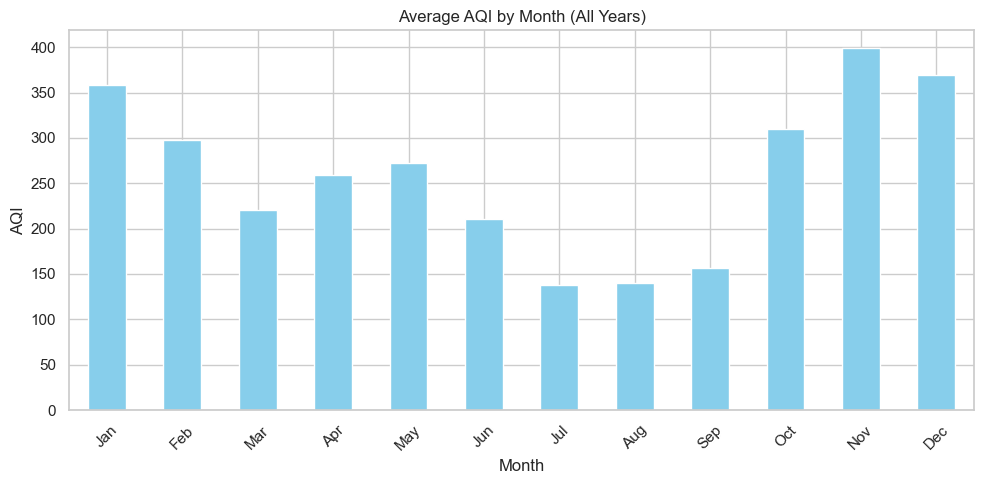

In [8]:
# Group by month across all years
monthly_avg = df['AQI'].groupby(df.index.month).mean()

# Plot
plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar', color='skyblue')
plt.title('Average AQI by Month (All Years)')
plt.xlabel('Month')
plt.ylabel('AQI')
plt.xticks(ticks=range(0,12), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
], rotation=45)
plt.tight_layout()
plt.show()


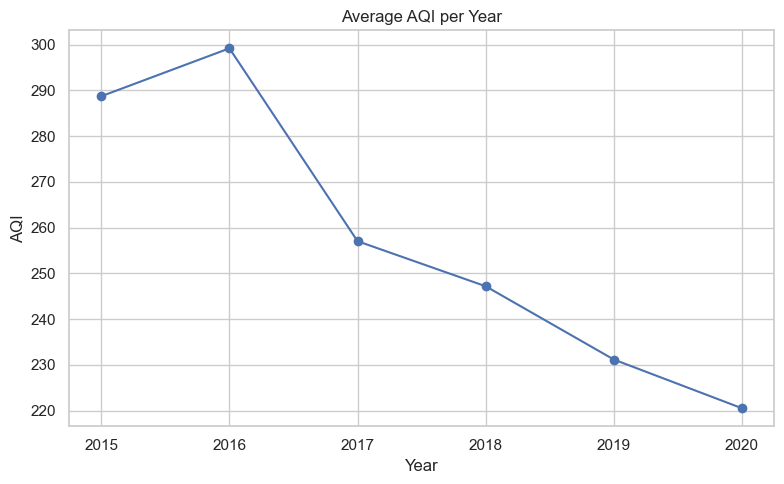

In [9]:
yearly_avg = df['AQI'].groupby(df.index.year).mean()

plt.figure(figsize=(8,5))
yearly_avg.plot(marker='o', linestyle='-')
plt.title('Average AQI per Year')
plt.xlabel('Year')
plt.ylabel('AQI')
plt.grid(True)
plt.tight_layout()
plt.show()


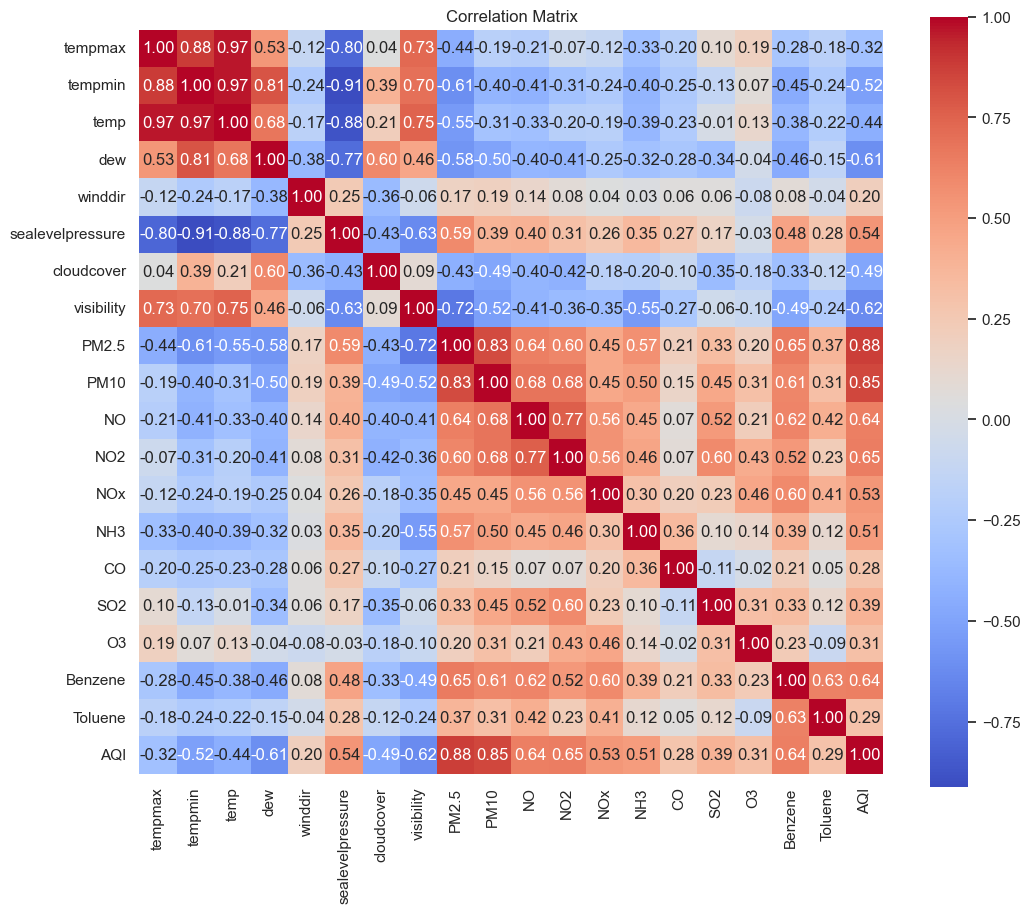

In [10]:
# Compute correlation with AQI
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()


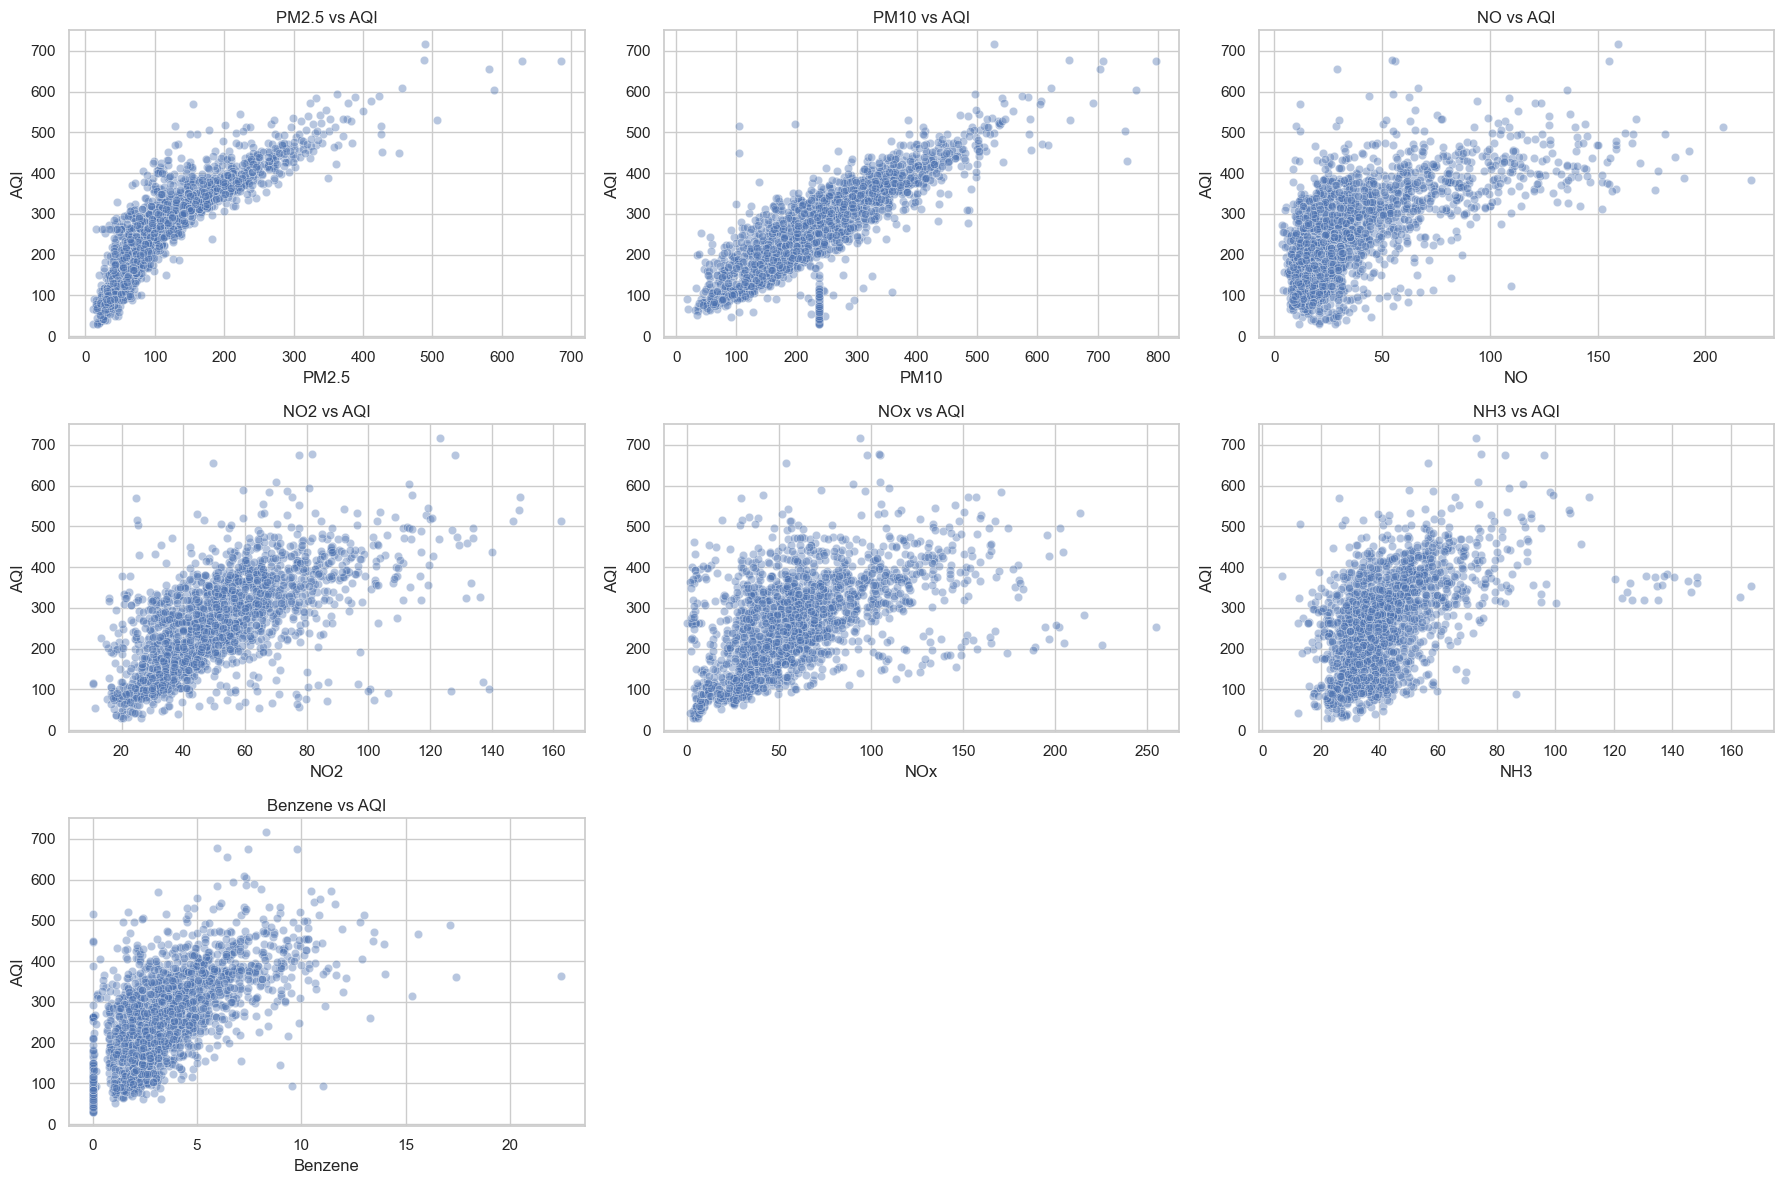

In [11]:
top_features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'Benzene']

plt.figure(figsize=(18, 12))

for i, feature in enumerate(top_features):
    plt.subplot(3, 3, i+1)
    sns.scatterplot(data=df, x=feature, y='AQI', alpha=0.4)
    plt.title(f'{feature} vs AQI')

plt.tight_layout()
plt.show()


In [12]:
# Backup the full DataFrame
df_cleaned = df.copy()

# Extract date features (optional, but may help)
df_cleaned['year'] = df_cleaned.index.year
df_cleaned['month'] = df_cleaned.index.month
df_cleaned['day'] = df_cleaned.index.day
df_cleaned['dayofweek'] = df_cleaned.index.dayofweek

# Define target and features
target = 'AQI'
X = df_cleaned.drop(columns=[target])
y = df_cleaned[target]

# Confirm shapes
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (1925, 23)
Target shape: (1925,)


In [13]:
from sklearn.model_selection import train_test_split

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size: {X_test.shape[0]} rows")


Train size: 1540 rows
Test size: 385 rows


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define all models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
}

# Train & evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n🔹 {name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.3f}")



🔹 Linear Regression
MAE: 29.61
RMSE: 40.31
R² Score: 0.876

🔹 Decision Tree
MAE: 31.00
RMSE: 43.23
R² Score: 0.858

🔹 Random Forest
MAE: 23.49
RMSE: 32.73
R² Score: 0.918

🔹 Gradient Boosting
MAE: 24.90
RMSE: 33.80
R² Score: 0.913

🔹 XGBoost
MAE: 23.44
RMSE: 32.89
R² Score: 0.918


In [15]:
import os
import joblib

# Create the folder outside 'notebooks/'
model_dir = "../saved_models"
os.makedirs(model_dir, exist_ok=True)

# Save the trained Random Forest model
model_path = os.path.join(model_dir, "random_forest_model.pkl")
joblib.dump(models["Random Forest"], model_path)

print(f"✅ Model saved to: {model_path}")


✅ Model saved to: ../saved_models\random_forest_model.pkl


In [4]:
import pandas as pd

# Load your cleaned dataset again
df = pd.read_csv("data/processed/processed_data.csv", parse_dates=["datetime"])
df.set_index("datetime", inplace=True)

# Backup
df_cleaned = df.copy()

# Add the features we engineered
df_cleaned['year'] = df_cleaned.index.year
df_cleaned['month'] = df_cleaned.index.month
df_cleaned['day'] = df_cleaned.index.day
df_cleaned['dayofweek'] = df_cleaned.index.dayofweek

# Drop the target column
X = df_cleaned.drop(columns=["AQI"])

# Print the list of columns used during training
print(X.columns.tolist())


FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/processed_data.csv'